In [1]:
import json
import boto3
import urllib3
from calendar import monthrange

s3 = boto3.client("s3")
http = urllib3.PoolManager()

BUCKET_NAME = "proyecto-electricidad-ela"
S3_KEY = "bronze/ree/ree_raw_2024_2025.json"

BASE_URL = "https://apidatos.ree.es/es/datos/balance/balance-electrico"

HEADERS = {
    "Accept": "application/json",
    "Content-Type": "application/json"
}

YEARS = [2024, 2025]

def lambda_handler(event, context):
    all_data = []

    for year in YEARS:
        for month in range(1, 13):
            last_day = monthrange(year, month)[1]

            url = (
                f"{BASE_URL}"
                f"?start_date={year}-{month:02d}-01T00:00"
                f"&end_date={year}-{month:02d}-{last_day:02d}T23:59"
                f"&time_trunc=day"
            )

            response = http.request("GET", url, headers=HEADERS)

            if response.status != 200:
                return {
                    "statusCode": response.status,
                    "body": f"Error consultando ESIOS {year}-{month:02d}"
                }

            data = json.loads(response.data.decode("utf-8"))

            all_data.append({
                "year": year,
                "month": month,
                "data": data
            })

    s3.put_object(
        Bucket=BUCKET_NAME,
        Key=S3_KEY,
        Body=json.dumps(all_data, ensure_ascii=False, indent=2).encode("utf-8"),
        ContentType="application/json"
    )

    return {
        "statusCode": 200,
        "body": f"ESIOS guardado en s3://{BUCKET_NAME}/{S3_KEY}"
    }

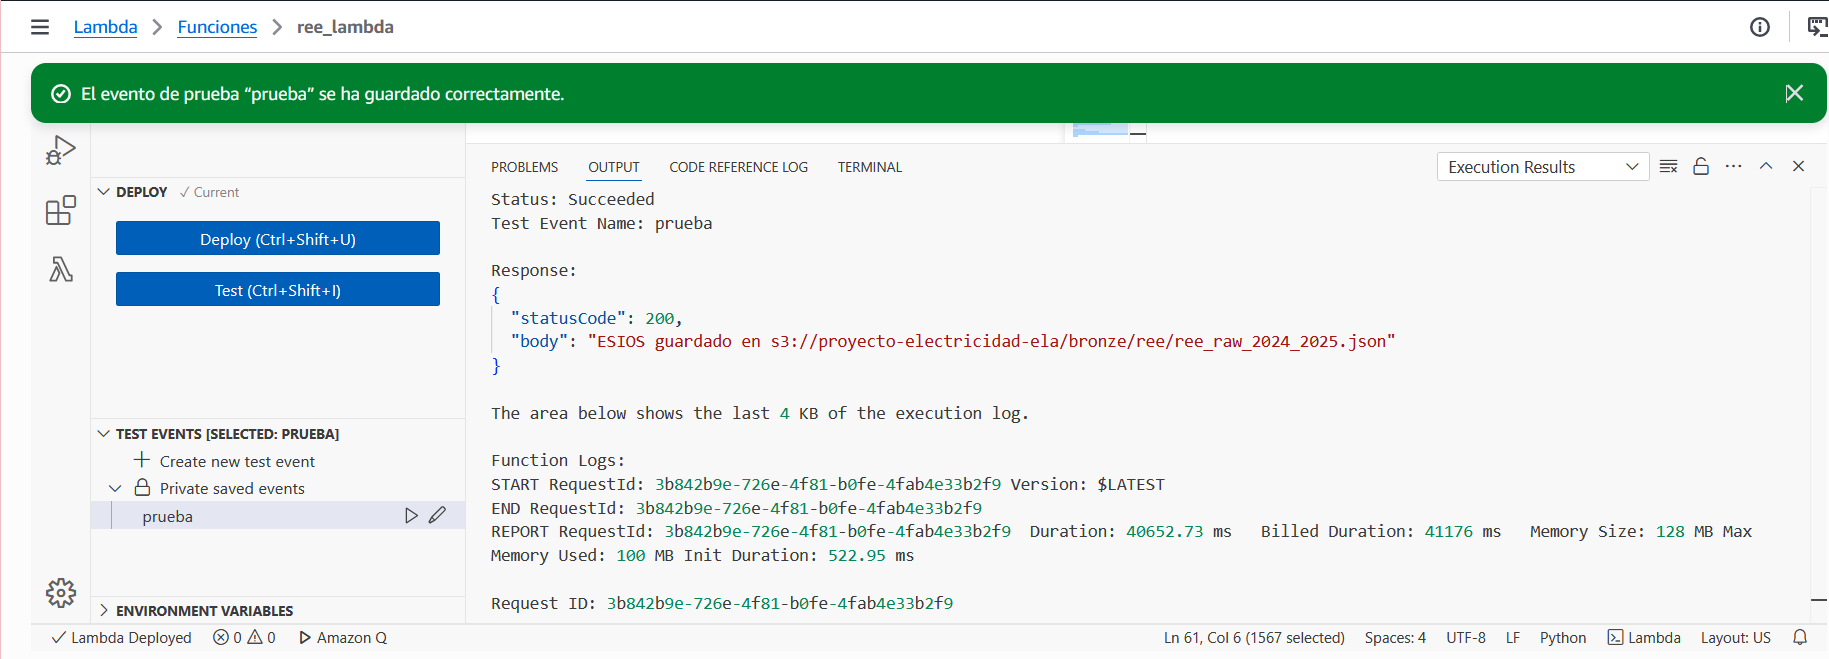